In [ ]:
import sys
print(sys.executable)

/home/yawpa/miniconda3/envs/lensengine/bin/python


In [ ]:
from lenstronomy.LensModel.lens_model import LensModel

lens_model_list = ['SIE']
lens_model = LensModel(lens_model_list=lens_model_list)

kwargs_lens = [{
    'theta_E': 1.2,
    'e1': 0.1,
    'e2': 0.05,
    'center_x': 0.0,
    'center_y': 0.0
}]

In [ ]:
from lenstronomy.LightModel.light_model import LightModel

source_model_list = ['SERSIC_ELLIPSE']
source_model = LightModel(light_model_list=source_model_list)

kwargs_source = [{
    'amp': 100,
    'R_sersic': 0.3,
    'n_sersic': 1.5,
    'e1': 0.05,
    'e2': -0.05,
    'center_x': 0.05,
    'center_y': 0.05
}]

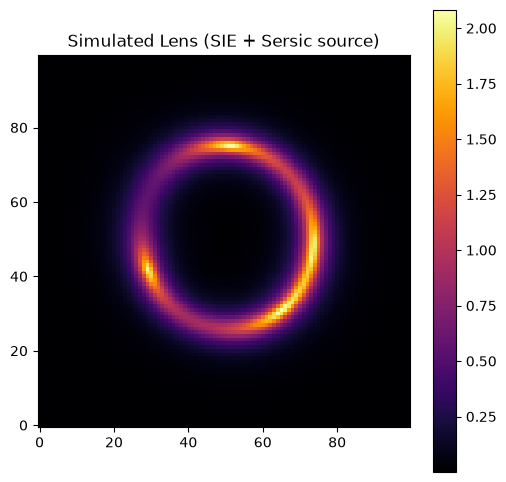

In [ ]:
import numpy as np
from lenstronomy.SimulationAPI.sim_api import SimAPI
import matplotlib.pyplot as plt

numPix = 100
deltaPix = 0.05

kwargs_data = {
    'pixel_scale': deltaPix,
    'exposure_time': 100,
    'magnitude_zero_point': 25.0,
    'sky_brightness': 22.0,
    'read_noise': 4,
    'ccd_gain': 2.5,
    'seeing': 0.1,
    'psf_type': 'GAUSSIAN'
}

sim_api = SimAPI(numpix=numPix, kwargs_single_band=kwargs_data, kwargs_model={
    'lens_model_list': lens_model_list,
    'source_light_model_list': source_model_list
})

image_model = sim_api.image_model_class()
image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Simulated Lens (SIE + Sersic source)")
plt.show()

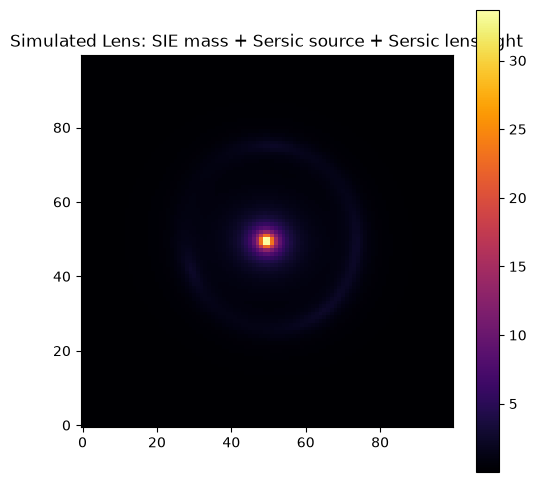

In [ ]:
lens_light_model_list = ['SERSIC_ELLIPSE']
lens_light_model = LightModel(light_model_list=lens_light_model_list)

kwargs_lens_light = [{
    'amp': 300,
    'R_sersic': 0.8,
    'n_sersic': 4,
    'e1': 0.05,
    'e2': -0.02,
    'center_x': 0.0,
    'center_y': 0.0
}]

sim_api = SimAPI(numpix=numPix, kwargs_single_band=kwargs_data, kwargs_model={
    'lens_model_list': lens_model_list,
    'source_light_model_list': source_model_list,
    'lens_light_model_list': lens_light_model_list
})

image_model = sim_api.image_model_class()
image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source, kwargs_lens_light=kwargs_lens_light)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Simulated Lens: SIE mass + Sersic source + Sersic lens light")
plt.show()

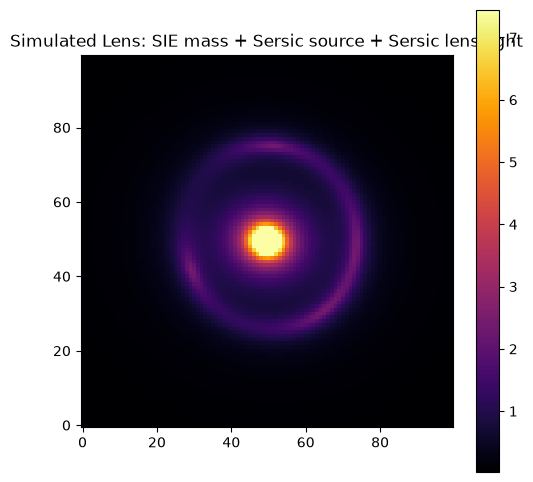

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='inferno', origin='lower', vmax=np.percentile(image, 99.5))
plt.colorbar()
plt.title("Simulated Lens: SIE mass + Sersic source + Sersic lens light")
plt.show()

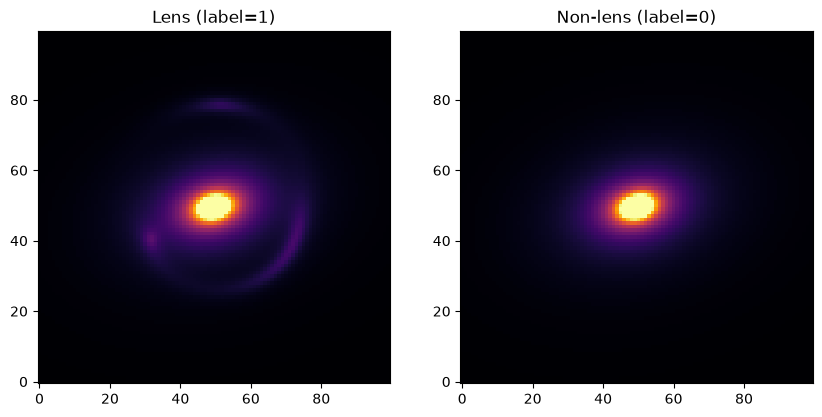

{'theta_E': 1.249448142616835, 'e1_lens': 0.18028572256396647, 'e2_lens': 0.09279757672456201, 'source_x': np.float64(0.09999602170806772), 'source_y': np.float64(0.14918469729049982), 'R_sersic_source': 0.1467983561008608, 'n_sersic_source': 1.1742508365045983, 'e1_source': 0.21970568746496105, 'e2_source': 0.06066900704592526, 'R_sersic_lens_light': 0.9956508044572319, 'amp_lens_light': 206.17534828874074}


In [ ]:
import sys
sys.path.append('../src')
import importlib
import lens_simulator
importlib.reload(lens_simulator)
from lens_simulator import generate_lens

result_lens = generate_lens(is_lens=True, seed=42)
result_nonlens = generate_lens(is_lens=False, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(result_lens['image'], cmap='inferno', origin='lower', vmax=np.percentile(result_lens['image'], 99.5))
axes[0].set_title(f"Lens (label={result_lens['label']})")
axes[1].imshow(result_nonlens['image'], cmap='inferno', origin='lower', vmax=np.percentile(result_nonlens['image'], 99.5))
axes[1].set_title(f"Non-lens (label={result_nonlens['label']})")
plt.show()

print(result_lens['metadata'])

In [ ]:
import h5py
import pandas as pd
print(h5py.__version__, pd.__version__)

3.16.0 3.0.5


In [ ]:
importlib.reload(lens_simulator)
from lens_simulator import generate_dataset

h5_path, parquet_path = generate_dataset(n_lens=5, n_nonlens=5, output_dir='../data/processed/test_run', seed_start=1000)

Generating non-lens images: 100%|██████████| 5/5 [00:00<00:00, 124.22it/s]


Saved 10 images to ../data/processed/test_run/lens_dataset.h5
Saved metadata (10 rows) to ../data/processed/test_run/lens_dataset_metadata.parquet
Label distribution:
label
1    5
0    5
Name: count, dtype: int64


(10, 100, 100) float32
(10, 14)


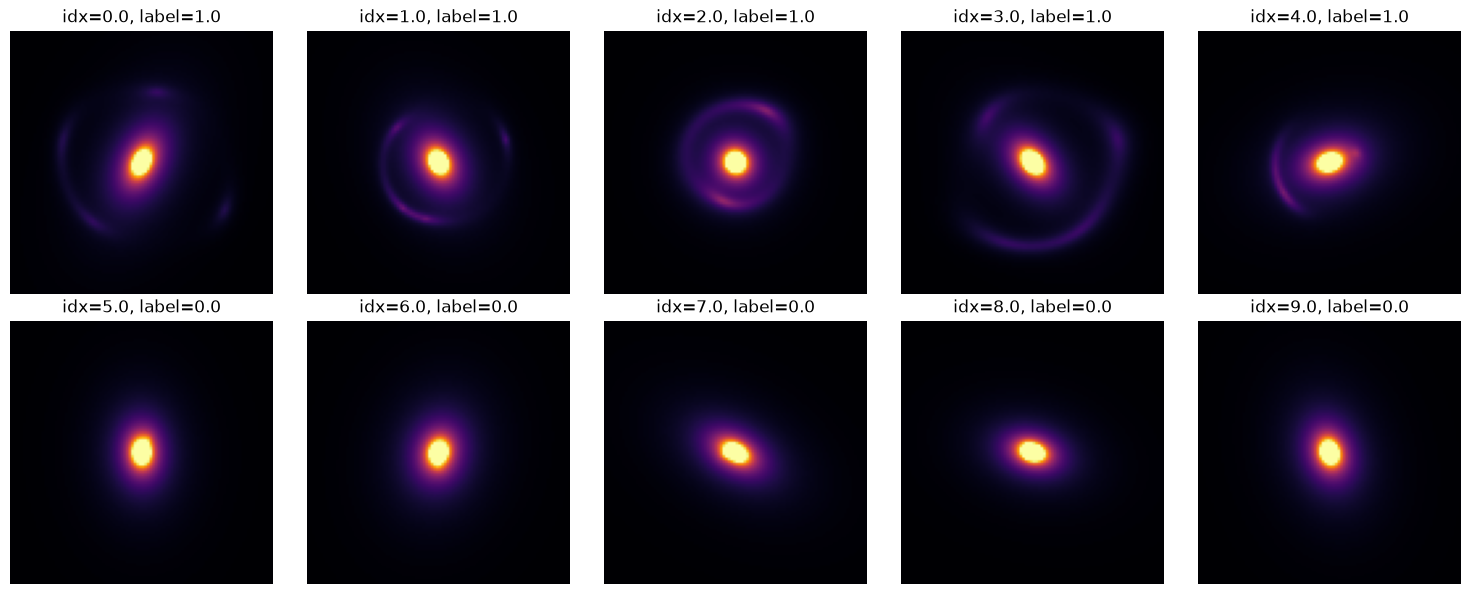

In [ ]:
with h5py.File(h5_path, 'r') as f:
    print(f['images'].shape, f['images'].dtype)
    loaded_images = f['images'][:]

loaded_metadata = pd.read_parquet(parquet_path)
print(loaded_metadata.shape)
loaded_metadata.head()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(loaded_images[i], cmap='inferno', origin='lower', vmax=np.percentile(loaded_images[i], 99.5))
    ax.set_title(f"idx={loaded_metadata.iloc[i]['index']}, label={loaded_metadata.iloc[i]['label']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Max difference (source contribution only): 1.823651468406009


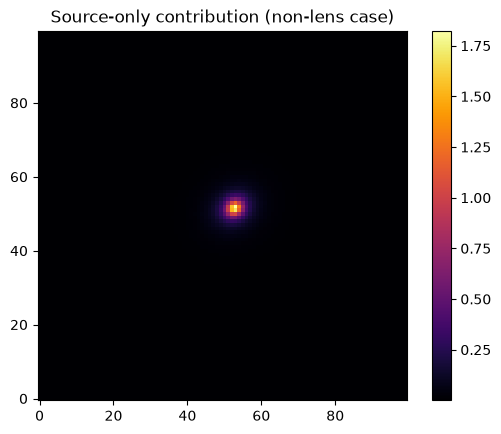

In [ ]:
result_check = generate_lens(is_lens=False, seed=999)

# Render the lens galaxy's light ALONE, with no source at all, for comparison
lens_light_model_only = LightModel(light_model_list=['SERSIC_ELLIPSE'])

kwargs_data_check = {
    'pixel_scale': 0.05, 'exposure_time': 100, 'magnitude_zero_point': 25.0,
    'sky_brightness': 22.0, 'read_noise': 4, 'ccd_gain': 2.5,
    'seeing': 0.1, 'psf_type': 'GAUSSIAN'
}
sim_api_check = SimAPI(numpix=100, kwargs_single_band=kwargs_data_check, kwargs_model={
    'lens_model_list': [], 'source_light_model_list': [], 'lens_light_model_list': ['SERSIC_ELLIPSE']
})
image_lens_only = sim_api_check.image_model_class().image(
    kwargs_lens=[], kwargs_source=[],
    kwargs_lens_light=[{
        'amp': result_check['metadata']['amp_lens_light'],
        'R_sersic': result_check['metadata']['R_sersic_lens_light'],
        'n_sersic': 4, 'e1': result_check['metadata']['e1_lens'], 'e2': result_check['metadata']['e2_lens'],
        'center_x': 0.0, 'center_y': 0.0
    }]
)

diff = result_check['image'] - image_lens_only
print("Max difference (source contribution only):", np.max(diff))
plt.imshow(diff, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Source-only contribution (non-lens case)")
plt.show()

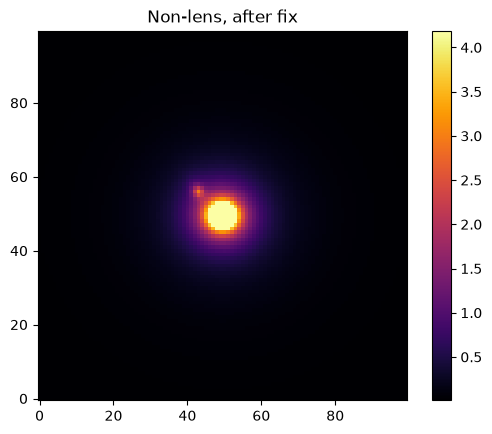

In [ ]:
importlib.reload(lens_simulator)
from lens_simulator import generate_lens

result_check2 = generate_lens(is_lens=False, seed=2000)
plt.imshow(result_check2['image'], cmap='inferno', origin='lower', vmax=np.percentile(result_check2['image'], 99.5))
plt.title("Non-lens, after fix")
plt.colorbar()
plt.show()

Generating non-lens images: 100%|██████████| 5/5 [00:00<00:00, 143.41it/s]


Saved 10 images to ../data/processed/test_run_v2/lens_dataset.h5
Saved metadata (10 rows) to ../data/processed/test_run_v2/lens_dataset_metadata.parquet
Label distribution:
label
1    5
0    5
Name: count, dtype: int64


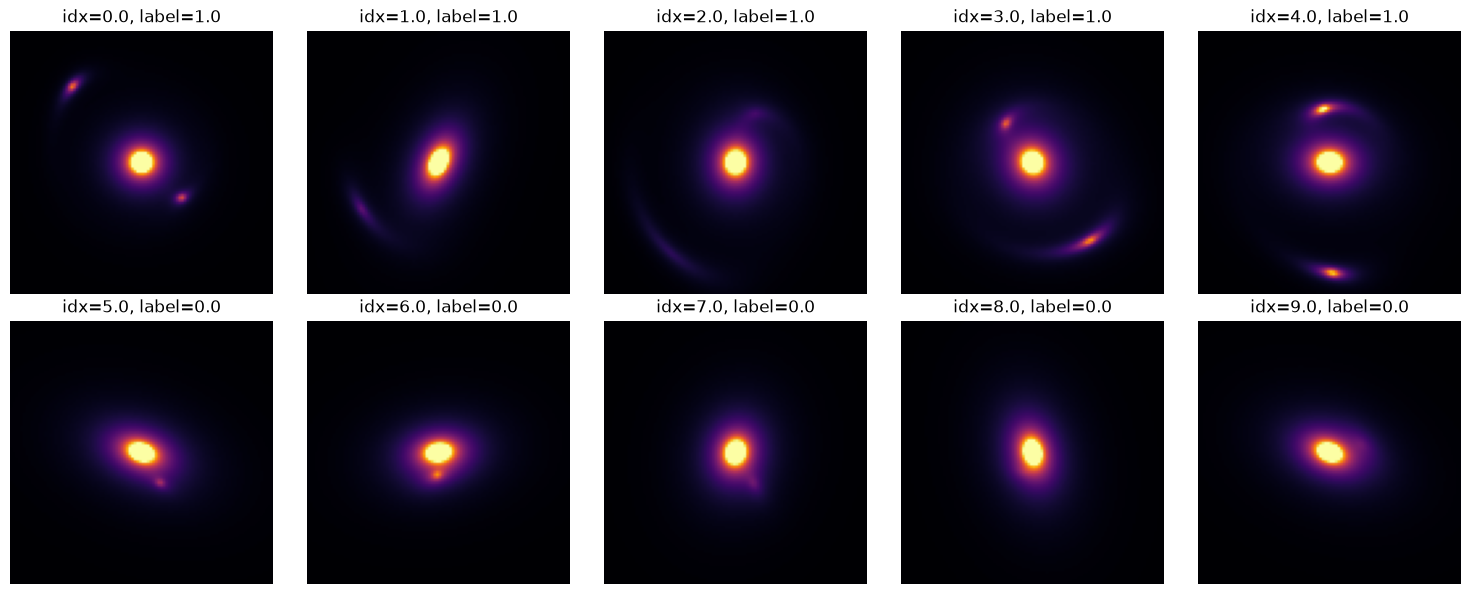

In [ ]:
h5_path, parquet_path = generate_dataset(n_lens=5, n_nonlens=5, output_dir='../data/processed/test_run_v2', seed_start=2000)

with h5py.File(h5_path, 'r') as f:
    loaded_images = f['images'][:]
loaded_metadata = pd.read_parquet(parquet_path)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(loaded_images[i], cmap='inferno', origin='lower', vmax=np.percentile(loaded_images[i], 99.5))
    ax.set_title(f"idx={loaded_metadata.iloc[i]['index']}, label={loaded_metadata.iloc[i]['label']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
h5_path, parquet_path = generate_dataset(n_lens=2000, n_nonlens=2000, output_dir='../data/processed/v1', seed_start=0)

Generating non-lens images: 100%|██████████| 2000/2000 [00:05<00:00, 395.59it/s]


Saved 4000 images to ../data/processed/v1/lens_dataset.h5
Saved metadata (4000 rows) to ../data/processed/v1/lens_dataset_metadata.parquet
Label distribution:
label
1    2000
0    2000
Name: count, dtype: int64


In [ ]:
with h5py.File(h5_path, 'r') as f:
    all_images = f['images'][:]
print(all_images.shape, all_images.dtype)
print("Any NaNs:", np.isnan(all_images).any())
print("Any all-zero images:", (all_images.reshape(4000, -1).sum(axis=1) == 0).any())

metadata_full = pd.read_parquet(parquet_path)
print(metadata_full['label'].value_counts())
print(metadata_full[['theta_E', 'source_x', 'source_y', 'R_sersic_source', 'e1_lens']].describe())
print("Duplicate seeds:", metadata_full['seed'].duplicated().any())

(4000, 100, 100) float32
Any NaNs: False
Any all-zero images: False
label
1    2000
0    2000
Name: count, dtype: int64
           theta_E     source_x     source_y  R_sersic_source      e1_lens
count  4000.000000  4000.000000  4000.000000      4000.000000  4000.000000
mean      1.387742    -0.000180    -0.011758         0.250125    -0.002061
std       0.351432     0.400309     0.398442         0.087156     0.115488
min       0.800627    -0.790197    -0.784226         0.100041    -0.199970
25%       1.077486    -0.339079    -0.346040         0.175729    -0.100833
50%       1.377954     0.001372    -0.021983         0.248140    -0.003203
75%       1.695287     0.332911     0.329803         0.325446     0.097702
max       1.999639     0.796074     0.794445         0.399992     0.199979
Duplicate seeds: False


In [ ]:
import os
import requests

username = os.environ.get('SSP_PDR_USR')
password = os.environ.get('SSP_PDR_PWD')

print("Credentials loaded:", username is not None, password is not None)

url = "https://hsc-release.mtk.nao.ac.jp/das_cutout/pdr2/cgi-bin/cutout"
params = {
    'ra1': 150.091, 'dec1': 2.20592,
    'ra2': 150.121, 'dec2': 2.23592,
    'type': 'coadd', 'image': 'on', 'mask': 'off', 'variance': 'off',
    'filter': 'HSC-I', 'rerun': 'pdr2_dud'
}

response = requests.get(url, params=params, auth=(username, password))
print(response.status_code)
print(response.headers.get('Content-Type'))
print(len(response.content), "bytes")

Credentials loaded: False False
401
text/html
188 bytes
